<a href="https://colab.research.google.com/github/eteitelbaum/code-satp/blob/main/models/classification-models/targettype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%reset -f

In [2]:
!pip install transformers datasets torch scikit-learn scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## Create A Fixed Split Where 10% is Reserved for Validation and 10% for Testing

In [21]:
def create_fixed_splits(df_full, stratify_cols, test_size=0.2, val_size=0.1, random_state=42):
    """
    Splits a multi-label classification dataset into fixed training, validation, and test sets
    using iterative stratification to preserve label distributions across splits.

    This function is designed for experiments where:
      - The test set must remain fixed across all model runs.
      - The validation set is also fixed and used for model selection.
      - Only the training set is progressively sampled in size.

    Parameters:
        df_full (pd.DataFrame): Full labeled dataset, including the input text column and multi-label targets.
        stratify_cols (list of str): Column names representing the multi-label targets used for stratification.
        test_size (float): Fraction of the full dataset to reserve as the test set (default: 0.2).
        val_size (float): Fraction of the remaining training pool to use as the validation set (default: 0.1).
        random_state (int): Seed for reproducibility.

    Returns:
        df_train_pool (pd.DataFrame): Training pool to draw progressively larger subsets from.
        df_val (pd.DataFrame): Fixed validation set (real-only, for model tuning).
        df_test (pd.DataFrame): Fixed test set (real-only, for final evaluation).

    Notes:
        - All DataFrames returned preserve the original index from df_full.
        - Iterative stratification ensures that rare labels are proportionally distributed across splits.
    """

    # Extract text and multi-label target arrays
    X = df_full["incident_summary"].values
    y = df_full[stratify_cols].values

    # Step 1: Split full data into train+val vs. test using iterative stratification
    stratifier = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - test_size, test_size]
    )
    for trainval_idx, test_idx in stratifier.split(X, y):
        break

    # Use .iloc to preserve original DataFrame indices
    df_trainval = df_full.iloc[trainval_idx]
    df_test = df_full.iloc[test_idx]

    # Step 2: Split trainval into training pool vs. validation set
    X_trainval = df_trainval["incident_summary"].values
    y_trainval = df_trainval[stratify_cols].values

    stratifier2 = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - val_size, val_size]
    )
    for train_idx, val_idx in stratifier2.split(X_trainval, y_trainval):
        break

    df_train_pool = df_trainval.iloc[train_idx]
    df_val = df_trainval.iloc[val_idx]

    return df_train_pool, df_val, df_test

## Previous Method--Create New Spit with Each Iteration

In [ ]:
# import numpy as np
# import pandas as pd
# from skmultilearn.model_selection import IterativeStratification

# def iterative_train_test_split_custom(X, y, test_size, random_state=None):
#     """
#     Splits X and y using iterative stratification and returns data + indices.
#     """
#     stratifier = IterativeStratification(
#         n_splits=2,
#         order=1,
#         sample_distribution_per_fold=[1 - test_size, test_size]
#     )

#     indices = np.arange(len(X))
#     for train_idx, test_idx in stratifier.split(X, y):
#         return (
#             X[test_idx], y[test_idx], test_idx,
#             X[train_idx], y[train_idx], train_idx
#         )


# def stratified_split(df, x_col, stratify_cols, test_size, val_size=None, random_state=None, return_indices=False):
#     """
#     Splits a DataFrame into stratified sets using iterative stratification.

#     Parameters:
#       df           : pandas DataFrame.
#       x_col        : column name containing the features (e.g., "incident_summary").
#       stratify_cols: list of column names to use for stratification.
#       train_size   : fraction for training (used for information; priority is given to training and validation).
#       test_size    : fraction for test set.
#       val_size     : (optional) fraction for validation set. If None, a two-split (train/test) is performed.
#       random_state : seed for reproducibility.

#     Returns:
#       If val_size is None:
#          (X_train, y_train, X_test, y_test)
#       Else:
#          (X_train, y_train, X_val, y_val, X_test, y_test)

#     Note: When using a validation set, it is assumed that train_size + test_size + val_size == 1.
#     """
#     # Shuffle the DataFrame if a random state is provided.
#     if random_state is not None:
#         df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

#     # Extract features and stratification labels.
#     X = df[x_col].values
#     y = df[stratify_cols].values

#     if val_size is None:
#         X_test, y_test, test_idx, X_train, y_train, train_idx = iterative_train_test_split_custom(X, y, test_size, random_state)

#         if return_indices:
#             return X_train, y_train, X_test, y_test, train_idx, test_idx
#         else:
#             return X_train, y_train, X_test, y_test

#     else:
#         temp_size = test_size + val_size
#         X_temp, y_temp, temp_idx, X_train, y_train, train_idx = iterative_train_test_split_custom(X, y, temp_size, random_state)

#         ratio = test_size / temp_size
#         X_test, y_test, test_idx, X_val, y_val, val_idx = iterative_train_test_split_custom(X_temp, y_temp, ratio, random_state)

#         if return_indices:
#             return X_train, y_train, X_val, y_val, X_test, y_test, train_idx, val_idx, test_idx
#         else:
#             return X_train, y_train, X_val, y_val, X_test, y_test


## Imports

In [22]:
import torch
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from skmultilearn.model_selection import IterativeStratification

## Dataset Class

In [23]:
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

## Metrics Function

In [24]:
def compute_metrics(eval_pred, target_names):
    """
    Compute evaluation metrics for multi-label classification.
    Includes Hamming Loss, Subset Accuracy, and Classification Report for all labels.
    """
    logits, labels = eval_pred
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
    labels = labels.astype(int)

    # Verify Labels
    print("Shape of labels:", labels.shape)  # Ensures correct dimensions
    print("First few rows of labels:\n", labels[:5])  # Shows the first few rows to check for issues
    print("Final target names:", target_names)

    # Hamming Loss
    hamming = hamming_loss(labels, predictions)

    # Subset Accuracy
    subset_acc = accuracy_score(labels, predictions)

    # Classification Report
    report = classification_report(
        labels, predictions,
        target_names=target_names,
        zero_division=0, output_dict=True
    )

    # Print complete report for reference
    print("\nFull Classification Report:")
    print(classification_report(labels, predictions, target_names=target_names, zero_division=0))


    # Summary Metrics for Trainer
    metrics = {
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
    }
    metrics.update(report)
    return metrics

## Model Training Function (Fixed Splits)

In [25]:
def train_transformer_model(model_name, df_train, df_val, df_test, max_len=512, batch_size=16, epochs=2):
    """
    Trains a transformer model for multi-label classification using fixed train/val/test splits.

    This version assumes the data has already been stratified and split externally,
    and that original DataFrame indices have been preserved for traceability.

    Parameters:
        model_name (str): Name or path of the pre-trained HuggingFace model to fine-tune.
        df_train (pd.DataFrame): Training set with 'incident_summary' and label columns.
        df_val (pd.DataFrame): Validation set for model selection and early stopping.
        df_test (pd.DataFrame): Test set used for final evaluation.
        max_len (int): Maximum input token length for the tokenizer (default: 512).
        batch_size (int): Batch size for both training and evaluation (default: 16).
        epochs (int): Number of fine-tuning epochs (default: 2).

    Returns:
        trainer (transformers.Trainer): The HuggingFace Trainer object after training.
        test_results (dict): Evaluation metrics on the test set.
        pred_df (pd.DataFrame): DataFrame with true labels, predictions, probabilities,
                                incident summary text, and original indices.
    """
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=df_train.shape[1] - 1,  # All columns except 'incident_summary'
        problem_type="multi_label_classification",
    )
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    # Identify label columns
    target_names = [col for col in df_train.columns if col != "incident_summary"]

    # Prepare datasets
    train_dataset = MultiLabelDataset(df_train["incident_summary"].tolist(), df_train[target_names].values, tokenizer, max_len)
    val_dataset = MultiLabelDataset(df_val["incident_summary"].tolist(), df_val[target_names].values, tokenizer, max_len)
    test_dataset = MultiLabelDataset(df_test["incident_summary"].tolist(), df_test[target_names].values, tokenizer, max_len)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model='eval_hamming_loss',
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
    )

    # Set up Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
    )

    # Train the model
    trainer.train()

    # Final evaluation on df_test (could be test or val depending on context)
    test_results = trainer.evaluate(test_dataset)
    predictions_output = trainer.predict(test_dataset)
    logits = predictions_output.predictions
    labels = predictions_output.label_ids

    # Convert to probabilities and binary predictions
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    binary_preds = (probs > 0.5).astype(int)

    # Build predictions DataFrame
    pred_df = pd.DataFrame()
    for i, col in enumerate(target_names):
        pred_df[f"true_{col}"] = labels[:, i]
        pred_df[f"pred_{col}"] = binary_preds[:, i]
        pred_df[f"prob_{col}"] = probs[:, i]

    pred_df["incident_summary"] = df_test["incident_summary"].values
    pred_df["original_idx"] = df_test.index

    return trainer, test_results, pred_df

## Older Training Function

In [ ]:

# # =======================
# # Reusable Training Function
# # =======================
# def train_transformer_model(model_name, data, max_len=512, test_size=0.1, val_size=0.1, batch_size=40, epochs=3):
#     """
#     Generalized function to train a transformer model for multi-label classification.
#     Args:
#         model_name: Name of the pre-trained model (e.g., "bert-base-uncased", "distilbert-base-uncased").
#         data: Pandas DataFrame with columns "incident_summary" and multi-label columns.
#         max_len: Maximum sequence length.
#         batch_size: Batch size for training and evaluation.
#         epochs: Number of training epochs.
#     """
#     # Load tokenizer and model
#     tokenizer = AutoTokenizer.from_pretrained(model_name)
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=data.shape[1] - 1,  # Number of labels (all columns except "incident_summary")
#         problem_type="multi_label_classification",
#     )
#     model.to("cuda" if torch.cuda.is_available() else "cpu")

#     target_names = data.drop(columns=["incident_summary"]).columns.tolist()

#     # Split data into train, val, and test
#     X = data["incident_summary"]
#     y = data.drop('incident_summary', axis=1).values

#     # Keep original indices
#     original_indices = X.index

#     # X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) #stratify=y)
#     # X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)




#     # X_train, y_train, X_test, y_test = stratified_split(
#     #     data,
#     #     x_col="incident_summary",
#     #     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     #     train_size=0.9,
#     #     test_size=0.1,
#     #     val_size=None,
#     #     random_state=42
#     # )

#     X_train, y_train, X_val, y_val, X_test, y_test, _, _, test_idx = stratified_split(
#         data,
#         x_col="incident_summary",
#         stratify_cols=[col for col in data.columns if col != "incident_summary"],
#         test_size=test_size,
#         val_size=val_size,
#         random_state=42,
#         return_indices=True
#     )


#     # Create datasets
#     train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer, max_len)
#     val_dataset = MultiLabelDataset(X_val.tolist(), y_val, tokenizer, max_len)
#     test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer, max_len)

#     # Define training arguments
#     training_args = TrainingArguments(
#         output_dir="./results",
#         eval_strategy="epoch",
#         save_strategy="epoch",
#         learning_rate=2e-5,
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         num_train_epochs=epochs,
#         weight_decay=0.01,
#         logging_dir="./logs",
#         logging_steps=10,
#         load_best_model_at_end=True,
#         metric_for_best_model='eval_hamming_loss',
#         greater_is_better=True,
#         save_total_limit=2,
#         report_to="none",
#     )

#     # Initialize Trainer
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         processing_class=tokenizer,
#         compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
#     )

#     # Train and Evaluate
#     trainer.train()

#     # Final Evaluation on Test Set
#     test_results = trainer.evaluate(test_dataset)
#     print("Test Set Results:", test_results)

#     # ---------------------------
#     # Generate Predictions on Test Set
#     # ---------------------------
#     predictions_output = trainer.predict(test_dataset)
#     logits = predictions_output.predictions
#     labels = predictions_output.label_ids

#     # Convert logits to probabilities
#     probs = torch.sigmoid(torch.tensor(logits)).numpy()

#     # Apply threshold to get binary predictions
#     binary_preds = (probs > 0.5).astype(int)

#     # Build predictions DataFrame
#     predictions_df = pd.DataFrame()
#     for i, col in enumerate(target_names):
#         predictions_df[f"true_{col}"] = labels[:, i]
#         predictions_df[f"pred_{col}"] = binary_preds[:, i]
#         predictions_df[f"prob_{col}"] = probs[:, i]

#     # Add original row index from the full dataset for traceability
#     predictions_df["original_idx"] = data.index[test_idx]

#     # Add original text summary for manual inspection of predictions
#     predictions_df["incident_summary"] = data.iloc[test_idx]["incident_summary"].values

#     return trainer, test_results, predictions_df


## Model Names and Labels

In [26]:
# List of Hugging Face model identifiers to evaluate
model_names = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

# Mapping from model name to human-readable label
model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

## Define Validation Experiments Function (Uses Validation Set)

In [27]:
def run_validation_experiments(
    df_train_pool,
    df_val,
    stratify_cols,
    output_csv="val_summary.csv",
    predictions_csv="val_predictions.csv",
    max_len=512,
    batch_size=16,
    epochs=2,
    fractions=[1/32, 1/16, 1/8, 1/4, 1/2, 1.0],
    model_names=None
):
    results_list = []
    all_predictions = []

    for frac in fractions:
        subset_size = int(len(df_train_pool) * frac)
        df_train_subset = df_train_pool.sample(n=subset_size, random_state=42)
        frac_label = f"{frac*100:.1f}%"

        for model_name in model_names:
            model_label = model_name_labels.get(model_name, model_name)
            print(f"\n=== VAL EXP | MODEL: {model_label} | FRACTION: {frac_label} ===")

            trainer, val_results, pred_df = train_transformer_model(
                model_name,
                df_train=df_train_subset,
                df_val=df_val,
                df_test=df_val,  # use val as holdout eval set
                max_len=max_len,
                batch_size=batch_size,
                epochs=epochs,
            )

            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }
            for key, value in val_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            results_list.append(run_result)
            pred_df["model"] = model_name
            pred_df["model_label"] = model_label
            pred_df["fraction"] = frac
            pred_df["fraction_label"] = frac_label
            all_predictions.append(pred_df)

    results_df = pd.DataFrame(results_list)
    results_df.to_csv(output_csv, index=False)
    full_pred_df = pd.concat(all_predictions, ignore_index=True)
    full_pred_df.to_csv(predictions_csv, index=False)

    return results_df, full_pred_df

## Define Final Experiments Function (Uses Test Set)

In [28]:
def run_final_test_evaluation(
    df_train_pool,
    df_val,
    df_test,
    stratify_cols,
    output_csv="test_summary.csv",
    predictions_csv="test_predictions.csv",
    max_len=512,
    batch_size=16,
    epochs=2,
    fractions=[1/32, 1/16, 1/8, 1/4, 1/2, 1.0],
    model_names=None
):
    """
    Runs post-tuning final experiments on the held-out test set by training models on
    progressively larger subsets of the training pool.

    This mirrors `run_validation_experiments()` but evaluates on the test set instead of the validation set.

    Parameters:
        df_train_pool (pd.DataFrame): Fixed training pool (from `create_fixed_splits()`).
        df_val (pd.DataFrame): Fixed validation set (for model selection during training).
        df_test (pd.DataFrame): Final held-out test set used for true evaluation.
        stratify_cols (list of str): Target column names for multi-label classification.
        output_csv (str): Output path for saving the summary of test results.
        predictions_csv (str): Output path for saving all test predictions.
        max_len (int): Max sequence length for tokenization.
        batch_size (int): Training/evaluation batch size.
        epochs (int): Number of training epochs.
        fractions (list of float): Fractions of training pool to use in experiments.
        model_names (list of str): HuggingFace model identifiers to evaluate.

    Returns:
        results_df (pd.DataFrame): Test metrics for all model/fraction combinations.
        full_pred_df (pd.DataFrame): Predictions with true labels and probabilities.
    """
    results_list = []
    all_predictions = []

    for frac in fractions:
        subset_size = int(len(df_train_pool) * frac)
        df_train_subset = df_train_pool.sample(n=subset_size, random_state=42)
        frac_label = f"{frac*100:.1f}%"

        for model_name in model_names:
            model_label = model_name_labels.get(model_name, model_name)
            print(f"\n=== FINAL TEST EVAL | MODEL: {model_label} | FRACTION: {frac_label} ===")

            trainer, test_results, pred_df = train_transformer_model(
                model_name,
                df_train=df_train_subset,
                df_val=df_val,
                df_test=df_test, # evaluate on holdout test set
                max_len=max_len,
                batch_size=batch_size,
                epochs=epochs
            )

            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }
            for key, value in test_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            results_list.append(run_result)

            pred_df["model"] = model_name
            pred_df["model_label"] = model_label
            pred_df["fraction"] = frac
            pred_df["fraction_label"] = frac_label
            all_predictions.append(pred_df)

    results_df = pd.DataFrame(results_list)
    results_df.to_csv(output_csv, index=False)
    full_pred_df = pd.concat(all_predictions, ignore_index=True)
    full_pred_df.to_csv(predictions_csv, index=False)

    print(f"Test results saved to {output_csv}")
    print(f"Test predictions saved to {predictions_csv}")
    return results_df, full_pred_df

## Older Experiments Function

In [ ]:
# def run_all_experiments_and_save(df_full, output_csv="results_summary.csv", predictions_csv="all_predictions.csv"):
#     """
#     1. Iterates over the defined fractions & model list
#     2. Samples df_full according to fraction
#     3. Trains & evaluates using train_multiclass_model_3way_split
#     4. Saves the collected results in a DataFrame
#     5. Exports to CSV

#     Args:
#         df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
#         output_csv (str): File path to save the experiment results.
#     Returns:
#         results_df (pd.DataFrame): Contains experiment results for analysis.
#     """
#     results_list = []

#     all_predictions = []

#     for frac in fractions:
#         # Sample a fraction of the data
#         subset_size = int(len(df_full) * frac)
#         df_subset = df_full.sample(n=subset_size, random_state=42)

#         # Friendly fraction label if you want
#         frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
#         print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

#         for model_name in models_list:
#             # Model label
#             model_label = model_name_labels.get(model_name, model_name)
#             print(f"Training model: {model_label}")

#             # Train & evaluate
#             # write the model funtion here
#             trainer, test_results, test_predictions = train_transformer_model(model_name, df_subset, max_len=512, test_size=0.1, val_size=0.1, batch_size=16, epochs=2)


#             # Build a result dict
#             run_result = {
#                 "fraction_raw": frac,
#                 "fraction_label": frac_label,
#                 "subset_size": subset_size,
#                 "model_raw": model_name,
#                 "model_label": model_label
#             }

#             # Flatten the nested dictionary
#             for key, value in test_results.items():
#                 if isinstance(value, dict):
#                     for subkey, subvalue in value.items():
#                         # Create new key names like "armed_assault_precision"
#                         run_result[f"{key}_{subkey}"] = subvalue
#                 else:
#                     run_result[key] = value

#             # Append to results_list
#             results_list.append(run_result)

#             # Add metadata columns
#             test_predictions["model"] = model_name
#             test_predictions["model_label"] = model_label
#             test_predictions["fraction"] = frac
#             test_predictions["fraction_label"] = frac_label

#             # Store in full list
#             all_predictions.append(test_predictions)

#     # Convert to DataFrame
#     results_df = pd.DataFrame(results_list)
#     # Save to CSV
#     results_df.to_csv(output_csv, index=False)
#     print(f"\nResults saved to {output_csv}")

#     # Concatenate and save all predictions
#     full_pred_df = pd.concat(all_predictions, ignore_index=True)
#     full_pred_df.to_csv(predictions_csv, index=False)
#     print("All predictions saved to all_predictions.csv")

#     # also save to JSON
#     # results_df.to_json("experiment_results.json", orient="records")

#     return results_df, full_pred_df


# **Read From Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/target_type.csv')

#**Read from GitHub**

In [30]:
import pandas as pd

# URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/refs/heads/main/data/target_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

           first_target second_target  civilians  maoist  \
0             Civilians     No Target          1       0   
1             No Target     No Target          0       0   
2                Maoist     No Target          0       1   
3  Government Officials     No Target          0       0   
4      Private Property       Unknown          0       0   

   government_officials  security  private_property  mining_company  ngos  \
0                     0         0                 0               0     0   
1                     0         0                 0               0     0   
2                     0         0                 0               0     0   
3                     1         0                 0               0     0   
4                     0         0                 1               0     0   

   government_infrastructure  ...  first_civilian_target  \
0                          0  ...                    NaN   
1                          0  ...                    NaN

## Select Relevant Columns

In [31]:
selected_columns = ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target', 'incident_summary']
data = data[selected_columns]

# Now 'data' contains only the selected columns.
print(data.head())


   civilians  maoist  government_officials  security  private_property  \
0          1       0                     0         0                 0   
1          0       0                     0         0                 0   
2          0       1                     0         0                 0   
3          0       0                     1         0                 0   
4          0       0                     0         0                 1   

   mining_company  ngos  government_infrastructure  non_maoist_armed_group  \
0               0     0                          0                       0   
1               0     0                          0                       0   
2               0     0                          0                       0   
3               0     0                          0                       0   
4               0     0                          0                       0   

   no_target                                   incident_summary  
0          0  An all

## Create Training, Validation and Test Sets

In [32]:
# Define your multi-label target columns
stratify_cols = [  # replace with actual label columns
    "civilians", "maoist", "government_officials", "security",
    "private_property", "mining_company", "ngos",
    "government_infrastructure", "non_maoist_armed_group", "no_target"
]

# Create fixed splits (once!)
df_train_pool, df_val, df_test = create_fixed_splits(
    data,
    stratify_cols=stratify_cols,
    test_size=0.1,
    val_size=0.111  # ~10% of original
)

## Run the Models

### Validation Phase

In [33]:
val_results_df, val_predictions_df = run_validation_experiments(
    df_train_pool,
    df_val,
    stratify_cols=stratify_cols,
    output_csv="val_summary.csv",
    predictions_csv="val_predictions.csv",
    model_names=model_names
)


=== VAL EXP | MODEL: BERT | FRACTION: 3.1% ===


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

...

Shape of labels: (885, 10)
First few rows of labels:
 [[0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00       141
                   maoist       0.56      0.85      0.67       398
     government_officials       0.00      0.00      0.00        47
                 security       0.00      0.00      0.00        92
         private_property       0.00      0.00      0.00        57
           mining_company       0.00      0.00      0.00         6
                     ngos       0.00      0.00      0.00         1
government_infrastructure       0.00      0.00      0.00        85
   

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Hamming Loss,Subset Accuracy,Civilians,Maoist,Government Officials,Security,Private Property,Mining Company,Ngos,Government Infrastructure,Non Maoist Armed Group,No Target,Micro avg,Macro avg,Weighted avg,Samples avg,Runtime,Samples Per Second,Steps Per Second
1,No log,0.605295,0.117288,0.446328,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 141.0}","{'precision': 0.44960362400906, 'recall': 0.9974874371859297, 'f1-score': 0.6198282591725215, 'support': 398.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 47.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 92.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 57.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 85.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 117.0}","{'precision': 0.44960362400906, 'recall': 0.4183350895679663, 'f1-score': 0.4334061135371179, 'support': 949.0}","{'precision': 0.044960362400906, 'recall': 0.09974874371859296, 'f1-score': 0.06198282591725215, 'support': 949.0}","{'precision': 0.18855873799326225, 'recall': 0.4183350895679663, 'f1-score': 0.2599490486308362, 'support': 949.0}","{'precision': 0.4485875706214689, 'recall': 0.44745762711864406, 'f1-score': 0.447834274952919, 'support': 949.0}",7.021300,126.045000,7.976000
2,0.637800,0.581648,0.117288,0.446328,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 141.0}","{'precision': 0.44960362400906, 'recall': 0.9974874371859297, 'f1-score': 0.6198282591725215, 'support': 398.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 47.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 92.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 57.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 85.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 117.0}","{'precision': 0.44960362400906, 'recall': 0.4183350895679663, 'f1-score': 0.4334061135371179, 'support': 949.0}","{'precision': 0.044960362400906, 'recall': 0.09974874371859296, 'f1-score': 0.06198282591725215, 'support': 949.0}","{'precision': 0.18855873799326225, 'recall': 0.4183350895679663, 'f1-score': 0.2599490486308362, 'support': 949.0}","{'precision': 0.4485875706214689, 'recall': 0.44745762711864406, 'f1-score': 0.447834274952919, 'support': 949.0}",7.023800,126.000000,7.973000


Shape of labels: (885, 10)
First few rows of labels:
 [[0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00       141
                   maoist       0.45      1.00      0.62       398
     government_officials       0.00      0.00      0.00        47
                 security       0.00      0.00      0.00        92
         private_property       0.00      0.00      0.00        57
           mining_company       0.00      0.00      0.00         6
                     ngos       0.00      0.00      0.00         1
government_infrastructure       0.00      0.00      0.00        85
   

Shape of labels: (885, 10)
First few rows of labels:
 [[0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00       141
                   maoist       0.45      1.00      0.62       398
     government_officials       0.00      0.00      0.00        47
                 security       0.00      0.00      0.00        92
         private_property       0.00      0.00      0.00        57
           mining_company       0.00      0.00      0.00         6
                     ngos       0.00      0.00      0.00         1
government_infrastructure       0.00      0.00      0.00        85
   

### Test Phase

In [ ]:
test_results_df, test_predictions_df = run_final_test_evaluation(
    df_train_pool,
    df_val,
    df_test,
    stratify_cols=stratify_cols,
    output_csv="test_summary.csv",
    predictions_csv="test_predictions.csv",
    model_names=model_names
)

## Commit Results to GitHub

In [ ]:
# commit csv to github using python

from github import Github
import pandas as pd
import os

# Replace with your GitHub personal access token
g = Github("your_github_access_token")

# Replace with your repository name and owner
repo = g.get_user("your_github_username").get_repo("your_repository_name")

# Specify the path to the CSV file in your Colab environment
csv_file_path = "experiment_results.csv"

# Check if the file exists
if not os.path.exists(csv_file_path):
    print(f"Error: CSV file '{csv_file_path}' not found.")
else:
    # Create a file object and commit
    try:
        with open(csv_file_path, 'rb') as file_obj:
            contents = repo.create_file(
                path="experiment_results.csv",  # Specify the path in your repository
                message="Committing CSV file from Colab",
                content=file_obj.read(),
                branch="main"  # Replace with your branch name
            )
        print("CSV file successfully committed to GitHub!")
    except Exception as e:
        print(f"Error committing CSV file to GitHub: {e}")


## Save to Disc

In [34]:
import os


def save_to_drive(df, filename, folder_name="targettype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(val_results_df, "targettype_val_summary.csv")
#save_to_drive(val_predictions_df, "targettype_val_predictions.csv")
#save_to_drive(final_results_df, "targettype_summary.csv")
#save_to_drive(predictions_df, "targettype_predictions.csv")

✅ DataFrame saved to: /content/drive/MyDrive/colab/satp-results/targettype/targettype_val_summary.csv


In [41]:
val_results_df.head()

,fraction_raw,fraction_label,subset_size,model_raw,model_label,eval_loss,eval_hamming_loss,eval_subset_accuracy,eval_civilians_precision,eval_civilians_recall,...,eval_weighted avg_f1-score,eval_weighted avg_support,eval_samples avg_precision,eval_samples avg_recall,eval_samples avg_f1-score,eval_samples avg_support,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.03125,3.1%,3,bert-base-cased,BERT,0.720178,0.532542,0.000000,0.159322,1.000000,...,0.117896,949.0,0.094418,0.449153,0.154175,949.0,6.0123,147.198,9.314,2.0
1,0.03125,3.1%,3,snowood1/ConfliBERT-scr-cased,ConfliBERT,0.652081,0.301356,0.003390,0.147368,0.297872,...,0.295035,949.0,0.172981,0.475706,0.247447,949.0,5.9963,147.591,9.339,2.0
2,0.03125,3.1%,3,FacebookAI/roberta-base,RoBERTa,0.680228,0.364407,0.000000,0.160410,1.000000,...,0.317032,949.0,0.178060,0.676836,0.280226,949.0,5.9228,149.422,9.455,2.0
3,0.03125,3.1%,3,distilbert-base-cased,DistilBERT,0.668936,0.231073,0.000000,0.151832,0.205674,...,0.286239,949.0,0.218644,0.484181,0.298795,949.0,3.2881,269.155,17.031,2.0
4,0.03125,3.1%,3,xlnet-base-cased,XLNet,0.638345,0.272655,0.030508,0.121469,0.304965,...,0.359824,949.0,0.210643,0.527119,0.288808,949.0,13.5435,65.345,4.135,2.0


## Preliminary Analysis

In [40]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/targettype/targettype_val_summary.csv')

ValueError: Mountpoint must not already contain files

In [37]:
df = val_results_df

### F1 Micro

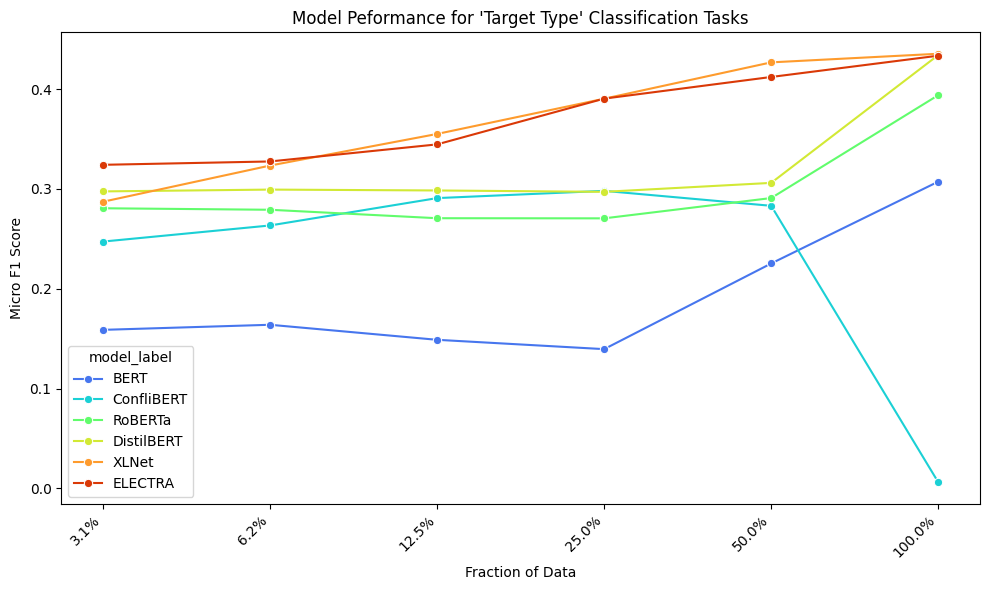

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="turbo"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Target Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Heatmap of individual labels

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Target Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x700 with 0 Axes>

### Model performance vs. speed

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="turbo"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


### Micro F1 vs. samples per second

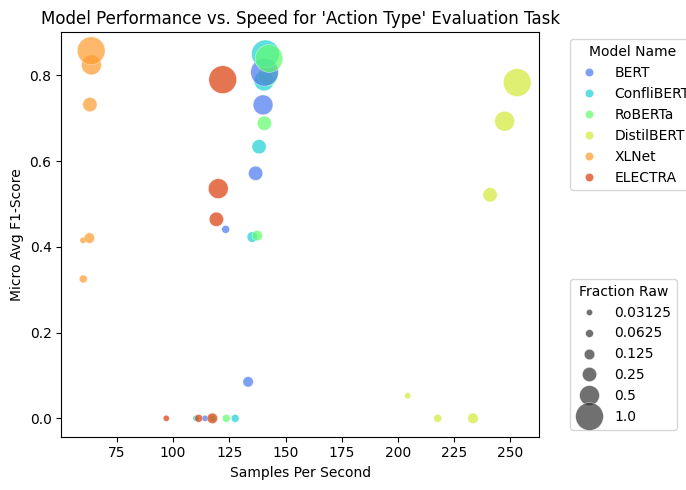

In [ ]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_micro avg_f1-score",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Target Type' Evaluation Task"
)